# Bepaling van warmtecapaciteit van een onbekend materiaal


# Introductie

Onbekende materialen kunnen geïdentificeerd worden door hun eigenschappen te meten. Een van deze eigenschappen is de warmtecapaciteit. In dit practicum gaan we de warmtecapaciteit van een onbekend materiaal bepalen door middel van een calorimeter experiment. Daarbij wordt een bepaalde massa van het materiaal naar een bekende temperatuur gebracht waarna het in een bekende hoeveelheid water met bekende temperatuur wordt geplaatst. Door de temperatuur van het water te meten na het mengen kan de warmtecapaciteit van het onbekende materiaal worden berekend.

# Theorie

De soortelijke warmte $c$ van een materiaal is gedefinieerd als de hoeveelheid warmte $Q$ die nodig is om de temperatuur $T$ van een kilogram van het materiaal met één graad Celsius (of één Kelvin) te verhogen:

$$
    c = \frac{Q}{m \Delta T}
$$ (eq:heat_capacity)

Waarbij $Q$ de hoeveelheid warmte in Joules is, $m$ de massa in kilogram is en $\Delta T$ de verandering in temperatuur is. Gegeven de wet van Black, die stelt dat de totale hoeveelheid warmte in een geïsoleerd systeem constant blijft, kunnen we de warmte die het onbekende materiaal verliest gelijkstellen aan de warmte die het water opneemt:

$$
    Q_{materiaal} = -Q_{water} 
$$ (eq:black)

wanneer we de massa's en de begintemperaturen van beide systemen kennen, maar slechts een van de twee soortelijke warmtes, kunnen we de onbekende soortelijke warmte berekenen. We combineren vergelijkingen [](#eq:heat_capacity) en [](#eq:black) om de volgende vergelijking te krijgen:

$$
    T_e = \frac{c_w m_w T_{w,b}+c_m m_m T_{m,b}}{c_w m_w + c_m m_m}
$$ (eq:combined)

Waarbij de subscripts $b$ en $e$ respectievelijk staan voor begintoestand en eindtoestand, $w$ voor water en $m$ voor het onbekende materiaal.

Bij metingen aan verschillende massa's van het onbekende materiaal en vervolgens een least square fit aan bovenstaande vergelijking kunnen we een precieze waarde voor de soortelijke warmte van het onbekende materiaal bepalen. Dat is, wanneer de warmtecapaciteit van bijvoorbeeld de beker te verwaarlozen is.


# Methode en materialen

## Ontwerp
De bovenstaande theorie wordt gebruikt om de soortelijke warmte van een onbekend materiaal te bepalen. Het experiment bestaat uit het verwarmen van verschillende massa's van het onbekende materiaal tot een bekende temperatuur, waarna het in een bekende hoeveelheid water met bekende temperatuur wordt geplaats. Door de temperatuur van het water te meten na het mengen kan de warmtecapaciteit van het onbekende materiaal worden berekend. Om de tijd voor het meten van meerdere materialen te reduceren, worden de data van de verschillende groepen in het lokaal samengevoegd. Van tevoren is afgesproken welke massa's door welke groep worden gemeten, en hoeveel water er gebruikt wordt.

## Materialen
Hieronder staat de lijst van benodigde materialen bij deze proef:
- Calorimeter
- Thermometer of temperatuursensor
- Verwarmingsbron 
- Diverse massablokjes van onbekend materiaal
- Weegschaal
- Water
- Maatcilinder of maatbeker


```{figure} figures/warmtecapaciteit_setup.png
:width: 70%
:label: fig_c_onbekend_setup

Een schematische weergave van de opstelling
```


## Procedure
Bespreek wie welke massa's van het onbekende materiaal gaat meten.
Bespreek ook hoeveel water er gebruikt gaat worden.
Bepaal de begintemperaturen.
Hevel het aantal afgesproken massa's in de maatbeker. 
Roer voorzicht zodat de temperatuur homogeen is.
Noteer de hoogste gemeten temperatuur, dit is $T_e$.
Wissel de metingen uit met de andere groepen en voer de data-analyse uit.

5 minuten equalizeren.
doe water in beker en meet hoelheid water en starttemperatuur
doe massa in beker en meet de hoogst behaalde temperatuur
herhaal

```{note}
Hieronder staat een voorbeeld hoe je een grafiek moet opslaan en vervolgens in je document kunt oproepen.
Het voorbeeld kun je natuurlijk straks verwijderen.
```

# Resultaten


Berekende soortelijke warmte van het onbekende materiaal: 384.37 ± 10.25 J/kg·K


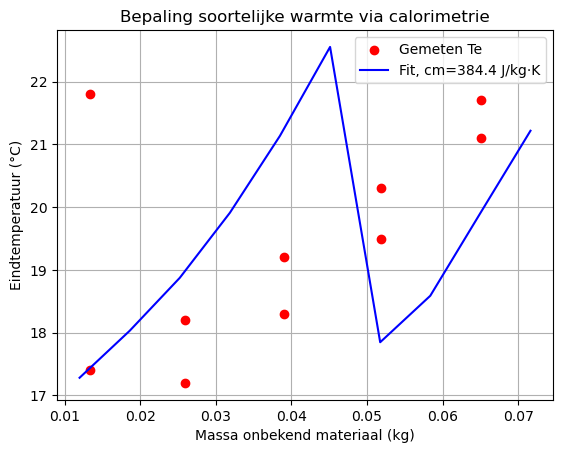

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# -------------------------------
# Meetwaarden invullen
# -------------------------------
# Massa van water (kg)
mw = np.array([202.2, 202.9, 202.9, 202.8, 202.8, 202.6, 195.4, 195.3, 195.2, 195.0]) *1e-3 # voorbeeld, vervang door jouw waarden

# Begin temperaturen water (°C)
Tw_b = np.array([17.0, 17.6, 18.3, 19.2, 20.3, 21.6, 16.6, 17.2, 18.4, 19.6])  # voorbeeld, vervang door jouw waarden

# Massa onbekend materiaal (kg)
mm = np.array([13.3, 25.9, 39.0, 51.9, 65.1, 13.3, 25.9, 39.0, 51.9, 65.1]) * 1e-3  # voorbeeld, vervang door jouw waarden

# Begin temperaturen onbekend materiaal (°C)
Tm_b = np.array([69.2, 69.2, 69.2, 69.2, 69.2, 69.2, 69.2, 69.2, 69.2, 69.2])  # voorbeeld, vervang door jouw waarden

# Gemeten eindtemperaturen (°C)
Te = np.array([17.4, 18.2, 19.2, 20.3, 21.7, 21.8, 17.2, 18.3, 19.5, 21.1])  # voorbeeld, vervang door jouw waarden

# Soortelijke warmte water (J/kg·K)
cw = 4186

# -------------------------------
# Functie voor curve fit
# -------------------------------
def eindtemp(mm, cm):
    """
    Bereken de voorspelde eindtemperatuur Te als functie van massa onbekend materiaal mm
    en soortelijke warmte cm
    """
    return (cw*mw*Tw_b + cm*mm*Tm_b) / (cw*mw + cm*mm)

# -------------------------------
# Least-squares fit om cm te vinden
# -------------------------------
# curve_fit verwacht x-data als 1D array; we gebruiken mm als onafhankelijke variabele
# extra parameters (mw, Tw_b, Tm_b, cw) worden via lambda meegegeven
popt, pcov = curve_fit(lambda mm, cm: eindtemp(mm, cm), mm, Te, p0=[400])
cm_fit = popt[0]
cm_err = np.sqrt(np.diag(pcov))[0]

print(f"Berekende soortelijke warmte van het onbekende materiaal: {cm_fit:.2f} ± {cm_err:.2f} J/kg·K")

# -------------------------------
# Plotten
# -------------------------------
mm_plot = np.linspace(min(mm)*0.9, max(mm)*1.1, 10)
Te_fit = eindtemp(mm_plot, cm_fit)

plt.scatter(mm, Te, color='red', label='Gemeten Te')
plt.plot(mm_plot, Te_fit, color='blue', label=f'Fit, cm={cm_fit:.1f} J/kg·K')
plt.xlabel('Massa onbekend materiaal (kg)')
plt.ylabel('Eindtemperatuur (°C)')
plt.title('Bepaling soortelijke warmte via calorimetrie')
plt.legend()
plt.grid(True)
plt.savefig("figures/warmtecapaciteit.png",dpi=450)
plt.show()


```{figure} figures/warmtecapaciteit.png
:width: 50%
:label: fig_naam 

```

# Discussie

In dit practicum is de soortelijke warmte van een onbekend materiaal bepaald door middel van een calorimeter experiment. Door verschillende massa’s van het materiaal op een bekende temperatuur te brengen en vervolgens in water met bekende massa en temperatuur te plaatsen, kon de warmte-uitwisseling worden gebruikt om de soortelijke warmte te berekenen.

De berekeningen met behulp van een least-squares fit gaven soortelijke warmte waarden van ongeveer 384 ± 10 J/kg·K en 385 ± 19 J/kg·K. Deze onzekerheid kan nog verbeterd worden d.m.v.:

- Meetfouten: kleine onnauwkeurigheden bij het aflezen van temperaturen of massa’s van water en materiaal.

- Warmteverliezen: het calorimeter-systeem is niet perfect geïsoleerd; een deel van de warmte kan verloren gaan aan de omgeving.

- Homogeniteit van het water: als het water niet volledig goed geroerd werd, kan de gemeten eindtemperatuur iets afwijken van de werkelijke gemiddelde temperatuur.

- Aanname van verwaarloosbare calorimeter: de berekening gaat ervan uit dat de warmtecapaciteit van de beker verwaarloosbaar is; dit kan een kleine systematische fout introduceren.

De foutmarges van ±10 J/kg·K is redelijk klein en duidt op een betrouwbare methode.

# Conclusie
Uit het experiment blijkt dat de soortelijke warmte van het onbekende materiaal ongeveer 384 J/kg·K bedraagt. Dit ligt in de orde van grootte van metalen zoals messing (≈380 J/kg·K) of koper (≈385 J/kg·K), wat een indicatie kan geven over de mogelijke samenstelling van het materiaal.

Het experiment toont aan dat calorimetrie een effectieve methode is om warmtecapaciteiten van onbekende materialen te bepalen, mits zorgvuldig wordt omgegaan met isolatie en meetnauwkeurigheid. Kleine verschillen tussen de datasets wijzen op experimentele onzekerheden, maar de methode levert toch een consistente schatting van de soortelijke warmte.